![lop](../../images/logo_diive1_128px.png)

<span style='font-size:32px; display:block;'>
<b>
    Calculate air temperature from sonic temperature
</b>
</span>

---
**Notebook version**: `1` (10 Nov 2025)  
**Author**: Lukas Hörtnagl (holukas@ethz.ch)  

</br>

# **Description**

- Calculate air temperature (`K`) from sonic temperature (`K`) and water vapor concentration (`mol mol-1`)
- Typically applied to high-resolution (10Hz, 20Hz) time series from eddy covariance measurements

</br>

# **Imports**

In [1]:
import importlib.metadata
import warnings
from datetime import datetime
import pandas as pd
from diive.pkgs.createvar.conversions import air_temp_from_sonic_temp

warnings.filterwarnings("ignore")
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")

diive version: v0.90.0


</br>

# **Docstring**

In [2]:
help(air_temp_from_sonic_temp)

Help on function air_temp_from_sonic_temp in module diive.pkgs.createvar.conversions:

air_temp_from_sonic_temp(sonic_temp: pandas.core.series.Series, h2o: pandas.core.series.Series) -> pandas.core.series.Series
    Calculate air temperature from sonic temperature and water vapor concentration.
    
    This function computes the air temperature from the provided sonic temperature
    and water vapor concentration using a specific formula. The calculation takes
    into account the relationship between sonic temperature, air temperature, and
    the effect of water vapor on sonic wave speed.
    
    Based on the code in:
    Striednig, M., Graus, M., Märk, T. D., & Karl, T. G. (2020). InnFLUX – an open-source
        code for conventional and disjunct eddy covariance analysis of trace gas measurements:
        An urban test case. Atmospheric Measurement Techniques, 13(3), 1447–1465.
        https://doi.org/10.5194/amt-13-1447-2020
        Source code: https://www.atm-phys-chem.at/innf

</br>

# **Create example data**
- Two pandas Series, one for sonic temperature, one for H2O mole fraction

In [3]:
# Sonic temperature in Kelvin
sonic_temp = pd.Series([287.549, 287.540, 287.552, 287.556, 287.559, 287.566, 287.560, 287.562, 287.557, 287.560], name='sonic_temp')

# H2O in mol mol-1
h2o = pd.Series([0.013417, 0.013453, 0.013492, 0.013419, 0.013476, 0.013503, 0.013463, 0.013472, 0.013521, 0.013481], name='h2o')

</br>

# **Calculate air temperature**
- Air temperture is returned in `K`

In [4]:
air_temp = air_temp_from_sonic_temp(sonic_temp=sonic_temp, h2o=h2o)
air_temp

0    286.319704
1    286.307458
2    286.315849
3    286.326491
4    286.324278
5    286.328785
6    286.326460
7    286.327630
8    286.318181
9    286.324818
Name: TA_SONIC, dtype: float64

</br>

# **Comparison**

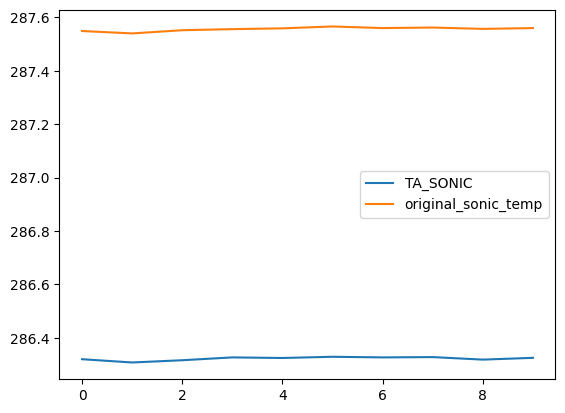

In [5]:
df = pd.DataFrame(air_temp)
df['original_sonic_temp'] = sonic_temp
df.plot();

</br>

# **End of notebook**

In [6]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished {dt_string}")

Finished 2025-11-10 11:30:08
